# LAB | Unsupervised Learning

## Unit 4.2 — Machine Learning, Part 2

In this notebook, I practice unsupervised learning using clustering and dimensionality reduction.

The lab has four main parts:

1. K-Means clustering on the Wine dataset.
2. Hierarchical and DBSCAN clustering on the Wine dataset.
3. Dimensionality reduction comparison on the Palmer Penguins dataset.
4. Evaluating whether unsupervised clustering can recover known species labels.

The main idea of unsupervised learning is that the model does not receive a target variable during training. Instead, it tries to discover hidden structure in the data.

## 1. Imports and Setup

This section imports all libraries needed for clustering, dimensionality reduction, evaluation, and visualization.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, MDS
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)

from scipy.cluster.hierarchy import dendrogram, linkage

RANDOM_STATE = 42

sns.set_theme(style="whitegrid")

## 2. Task 1 — K-Means Clustering on Wine

The goal of this task is to apply K-Means clustering to the Wine dataset.

K-Means groups data points around cluster centers called centroids. Since K-Means uses distance, the features must be scaled first. Otherwise, features with larger numeric ranges would dominate the distance calculation.

### 2.1 Load and Prepare Wine Data

In [2]:
wine = load_wine()

X_wine = pd.DataFrame(
    wine.data,
    columns=wine.feature_names
)

y_wine = pd.Series(wine.target, name="true_label")

print("Wine feature shape:", X_wine.shape)
display(X_wine.head())
print("Known classes in original dataset:", sorted(y_wine.unique()))

Wine feature shape: (178, 13)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


Known classes in original dataset: [np.int64(0), np.int64(1), np.int64(2)]


In [3]:
scaler_wine = StandardScaler()
X_wine_scaled = scaler_wine.fit_transform(X_wine)

print("Scaled Wine data shape:", X_wine_scaled.shape)
print("Mean after scaling:", np.round(X_wine_scaled.mean(axis=0)[:5], 3))
print("Std after scaling:", np.round(X_wine_scaled.std(axis=0)[:5], 3))

Scaled Wine data shape: (178, 13)
Mean after scaling: [ 0.  0. -0. -0. -0.]
Std after scaling: [1. 1. 1. 1. 1.]


### 2.2 Elbow Method and Silhouette Scores

To choose the number of clusters, I test K-Means with different values of `k`.

- **Inertia / WCSS** measures how compact the clusters are. Lower is better, but it naturally decreases as k increases.
- **Elbow method** looks for the point where inertia stops decreasing strongly.
- **Silhouette score** measures how well each point fits into its assigned cluster compared to the nearest other cluster. The score ranges from -1 to 1, where higher is better.

In [4]:
k_values = range(2, 11)

inertias = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_wine_scaled)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(X_wine_scaled, labels)
    )

kmeans_results = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
    "silhouette_score": silhouette_scores,
})

display(kmeans_results)

,k,inertia,silhouette_score
0,2,1658.758852,0.259317
1,3,1277.928489,0.284859
2,4,1175.428333,0.260170
3,5,1109.512739,0.201619
4,6,1046.002333,0.237167
5,7,981.595233,0.203628
6,8,935.201211,0.157014
7,9,889.892911,0.149882
8,10,845.895237,0.143638


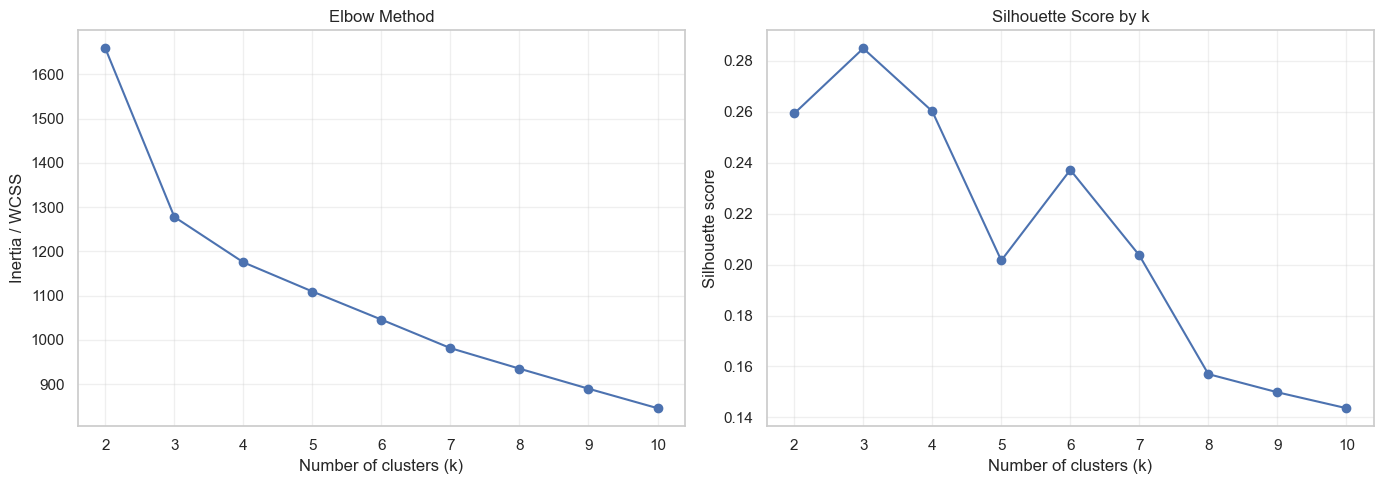

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(kmeans_results["k"], kmeans_results["inertia"], marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia / WCSS")
axes[0].grid(alpha=0.3)

axes[1].plot(kmeans_results["k"], kmeans_results["silhouette_score"], marker="o")
axes[1].set_title("Silhouette Score by k")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette score")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 2.3 Choosing the Optimal K

Based on the elbow curve and silhouette score, I choose the final number of clusters.

The Wine dataset is known to contain three cultivars, but in unsupervised learning the model does not use those labels during clustering. The labels are only useful later for evaluation.

In [6]:
optimal_k = 3

print("Chosen k:", optimal_k)

Chosen k: 3


**Interpretation**

I selected `k = 3`.

The elbow curve shows that the improvement in inertia becomes smaller after around 3 clusters. The silhouette score also helps evaluate whether the clusters are reasonably separated.

This choice is also meaningful because the original Wine dataset has three known wine classes, although these labels were not used by K-Means during clustering.

### 2.4 Final K-Means Model and PCA Visualization

In [7]:
kmeans_final = KMeans(
    n_clusters=optimal_k,
    random_state=RANDOM_STATE,
    n_init=10
)

wine_kmeans_labels = kmeans_final.fit_predict(X_wine_scaled)

print("Cluster labels:", np.unique(wine_kmeans_labels))
print("Cluster sizes:", np.bincount(wine_kmeans_labels))
print("Final inertia:", round(kmeans_final.inertia_, 2))
print("Final silhouette score:", round(silhouette_score(X_wine_scaled, wine_kmeans_labels), 3))

Cluster labels: [0 1 2]
Cluster sizes: [65 51 62]
Final inertia: 1277.93
Final silhouette score: 0.285


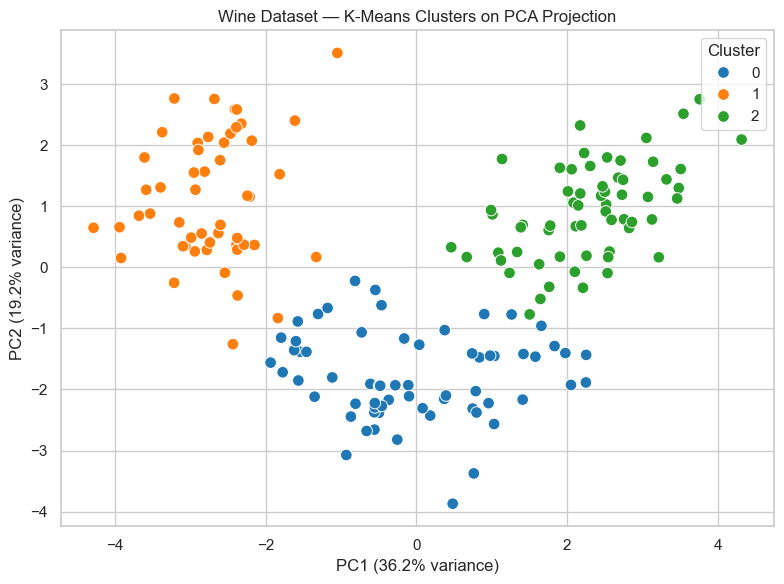

In [8]:
pca_wine = PCA(n_components=2, random_state=RANDOM_STATE)
X_wine_pca = pca_wine.fit_transform(X_wine_scaled)

wine_plot_df = pd.DataFrame({
    "PC1": X_wine_pca[:, 0],
    "PC2": X_wine_pca[:, 1],
    "kmeans_cluster": wine_kmeans_labels,
    "true_label": y_wine,
})

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=wine_plot_df,
    x="PC1",
    y="PC2",
    hue="kmeans_cluster",
    palette="tab10",
    s=70
)

plt.title("Wine Dataset — K-Means Clusters on PCA Projection")
plt.xlabel(f"PC1 ({pca_wine.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca_wine.explained_variance_ratio_[1]:.1%} variance)")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

**Task 1 Interpretation**

K-Means created clusters based only on the scaled chemical features of the wines. The PCA plot helps visualize these high-dimensional data points in two dimensions.

The clusters appear reasonably separated, although PCA is only a 2-D projection, so it does not show the full 13-dimensional structure of the dataset.

## 3. Task 2 — Hierarchical and Density-Based Clustering

In this task, I compare K-Means with two other clustering approaches:

1. **Agglomerative Clustering** — a hierarchical bottom-up method.
2. **DBSCAN** — a density-based method that can detect noise and does not require specifying k.

All methods are applied to the same scaled Wine dataset.

### 3.1 Agglomerative Clustering

In [9]:
agg_model = AgglomerativeClustering(
    n_clusters=optimal_k,
    linkage="ward"
)

wine_agg_labels = agg_model.fit_predict(X_wine_scaled)

print("Agglomerative cluster labels:", np.unique(wine_agg_labels))
print("Agglomerative cluster sizes:", np.bincount(wine_agg_labels))
print("Agglomerative silhouette score:", round(silhouette_score(X_wine_scaled, wine_agg_labels), 3))

Agglomerative cluster labels: [0 1 2]
Agglomerative cluster sizes: [58 56 64]
Agglomerative silhouette score: 0.277


### 3.2 Dendrogram

A dendrogram shows how individual points or clusters are merged step by step. I use Ward linkage because it minimizes within-cluster variance and is a common default for hierarchical clustering.

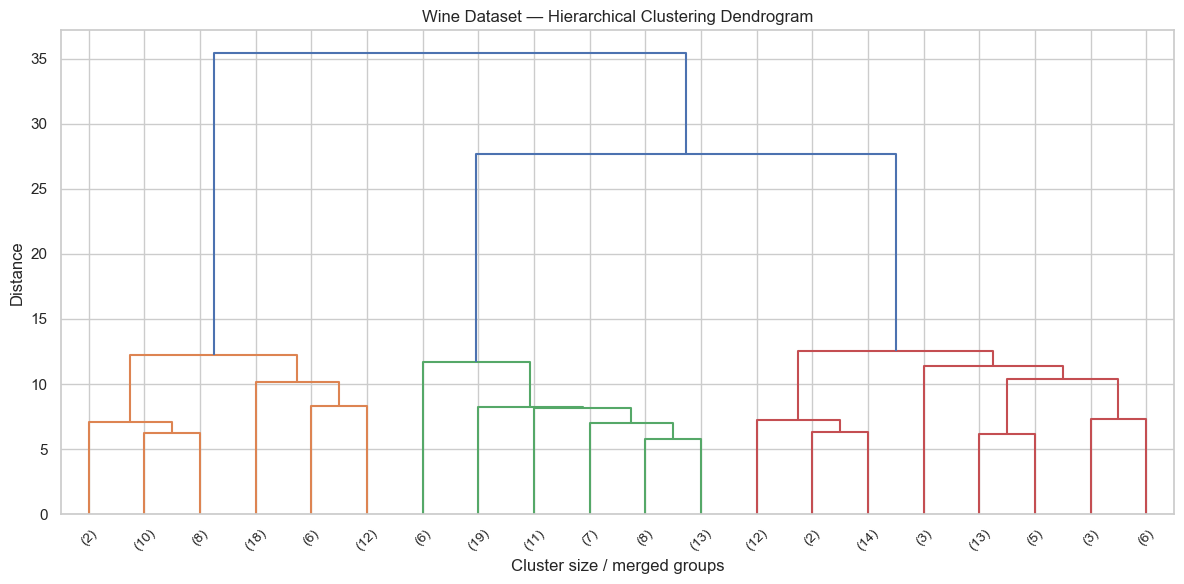

In [10]:
linked_wine = linkage(X_wine_scaled, method="ward")

plt.figure(figsize=(12, 6))

dendrogram(
    linked_wine,
    truncate_mode="lastp",
    p=20,
    leaf_rotation=45,
    leaf_font_size=10
)

plt.title("Wine Dataset — Hierarchical Clustering Dendrogram")
plt.xlabel("Cluster size / merged groups")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

### 3.3 DBSCAN Parameter Search

DBSCAN has two important parameters:

- `eps`: neighborhood radius
- `min_samples`: minimum number of nearby points needed to form a dense region

DBSCAN can find noise points. Noise points are labeled as `-1`.

In [11]:
dbscan_configs = [
    {"eps": 1.5, "min_samples": 5},
    {"eps": 2.0, "min_samples": 5},
    {"eps": 2.5, "min_samples": 5},
    {"eps": 3.0, "min_samples": 5},
    {"eps": 2.5, "min_samples": 3},
]

dbscan_results = []

for config in dbscan_configs:
    dbscan = DBSCAN(
        eps=config["eps"],
        min_samples=config["min_samples"]
    )
    
    labels = dbscan.fit_predict(X_wine_scaled)
    
    unique_labels = set(labels)
    n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
    n_noise = list(labels).count(-1)
    
    if n_clusters > 1:
        mask = labels != -1
        
        if len(set(labels[mask])) > 1:
            sil = silhouette_score(X_wine_scaled[mask], labels[mask])
        else:
            sil = np.nan
    else:
        sil = np.nan
    
    dbscan_results.append({
        "eps": config["eps"],
        "min_samples": config["min_samples"],
        "n_clusters": n_clusters,
        "n_noise": n_noise,
        "silhouette_without_noise": sil,
        "labels": labels,
    })

dbscan_results_df = pd.DataFrame(dbscan_results).drop(columns="labels")
display(dbscan_results_df)

,eps,min_samples,n_clusters,n_noise,silhouette_without_noise
0,1.5,5,0,178,NaN
1,2.0,5,5,85,0.240461
2,2.5,5,1,24,NaN
3,3.0,5,1,11,NaN
4,2.5,3,1,23,NaN


### 3.4 Select Best DBSCAN Configuration

In [12]:
dbscan_results_with_distance = []

for result in dbscan_results:
    distance_from_optimal_k = abs(result["n_clusters"] - optimal_k)
    
    dbscan_results_with_distance.append({
        **result,
        "distance_from_optimal_k": distance_from_optimal_k,
    })

best_dbscan_result = sorted(
    dbscan_results_with_distance,
    key=lambda x: (x["distance_from_optimal_k"], x["n_noise"])
)[0]

wine_dbscan_labels = best_dbscan_result["labels"]

print("Best DBSCAN configuration:")
print("eps:", best_dbscan_result["eps"])
print("min_samples:", best_dbscan_result["min_samples"])
print("Number of clusters:", best_dbscan_result["n_clusters"])
print("Number of noise points:", best_dbscan_result["n_noise"])
print("Unique labels:", sorted(set(wine_dbscan_labels)))

Best DBSCAN configuration:
eps: 3.0
min_samples: 5
Number of clusters: 1
Number of noise points: 11
Unique labels: [np.int64(-1), np.int64(0)]


### 3.5 Compare K-Means, Agglomerative, and DBSCAN

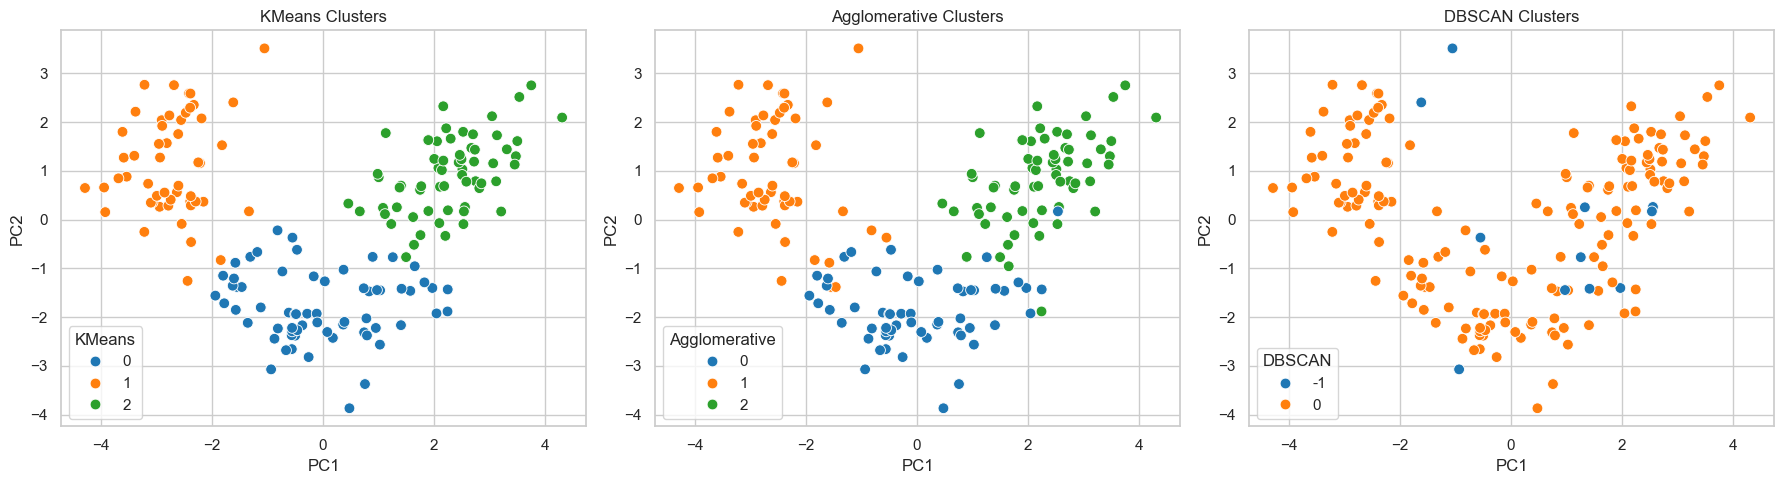

In [13]:
comparison_plot_df = pd.DataFrame({
    "PC1": X_wine_pca[:, 0],
    "PC2": X_wine_pca[:, 1],
    "KMeans": wine_kmeans_labels,
    "Agglomerative": wine_agg_labels,
    "DBSCAN": wine_dbscan_labels,
})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

methods = ["KMeans", "Agglomerative", "DBSCAN"]

for ax, method in zip(axes, methods):
    sns.scatterplot(
        data=comparison_plot_df,
        x="PC1",
        y="PC2",
        hue=method,
        palette="tab10",
        s=60,
        ax=ax,
        legend=True
    )
    
    ax.set_title(f"{method} Clusters")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.tight_layout()
plt.show()

**Task 2 Interpretation**

K-Means and Agglomerative Clustering are easier to compare because both use the selected number of clusters. Agglomerative clustering also gives a dendrogram, which helps visualize how clusters merge.

DBSCAN is different because it does not require choosing k in advance. Instead, it depends on density parameters such as `eps` and `min_samples`. It can also label some points as noise.

In this dataset, K-Means and Agglomerative are expected to produce more stable cluster partitions because the Wine dataset has compact groups in scaled feature space. DBSCAN is more sensitive to parameter choice here.

## 4. Task 3 — Dimensionality Reduction on Palmer Penguins

In this task, I compare three dimensionality reduction methods:

1. PCA
2. t-SNE
3. MDS

The goal is to reduce the Penguins numeric features to 2-D and compare how well the three species are visually separated.

### 4.1 Load and Prepare Penguins Data

In [14]:
penguins = sns.load_dataset("penguins")

print("Original Penguins shape:", penguins.shape)
display(penguins.head())
display(penguins.isna().sum())

Original Penguins shape: (344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [15]:
penguins_clean = penguins.dropna().copy()

numeric_cols = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
]

X_penguins = penguins_clean[numeric_cols].copy()
y_penguins = penguins_clean["species"].copy()

scaler_penguins = StandardScaler()
X_penguins_scaled = scaler_penguins.fit_transform(X_penguins)

print("Clean Penguins shape:", penguins_clean.shape)
print("Numeric feature shape:", X_penguins_scaled.shape)
print("Species:", sorted(y_penguins.unique()))

Clean Penguins shape: (333, 7)
Numeric feature shape: (333, 4)
Species: ['Adelie', 'Chinstrap', 'Gentoo']


### 4.2 Apply PCA, t-SNE, and MDS

In [16]:
pca_penguins = PCA(n_components=2, random_state=RANDOM_STATE)
X_penguins_pca = pca_penguins.fit_transform(X_penguins_scaled)

tsne_penguins = TSNE(
    n_components=2,
    perplexity=30,
    random_state=RANDOM_STATE,
    init="pca",
    learning_rate="auto"
)
X_penguins_tsne = tsne_penguins.fit_transform(X_penguins_scaled)

mds_penguins = MDS(
    n_components=2,
    random_state=RANDOM_STATE,
    n_init=4,
    max_iter=300
)
X_penguins_mds = mds_penguins.fit_transform(X_penguins_scaled)

print("PCA shape:", X_penguins_pca.shape)
print("t-SNE shape:", X_penguins_tsne.shape)
print("MDS shape:", X_penguins_mds.shape)

PCA shape: (333, 2)
t-SNE shape: (333, 2)
MDS shape: (333, 2)


### 4.3 Visualize Dimensionality Reduction Methods

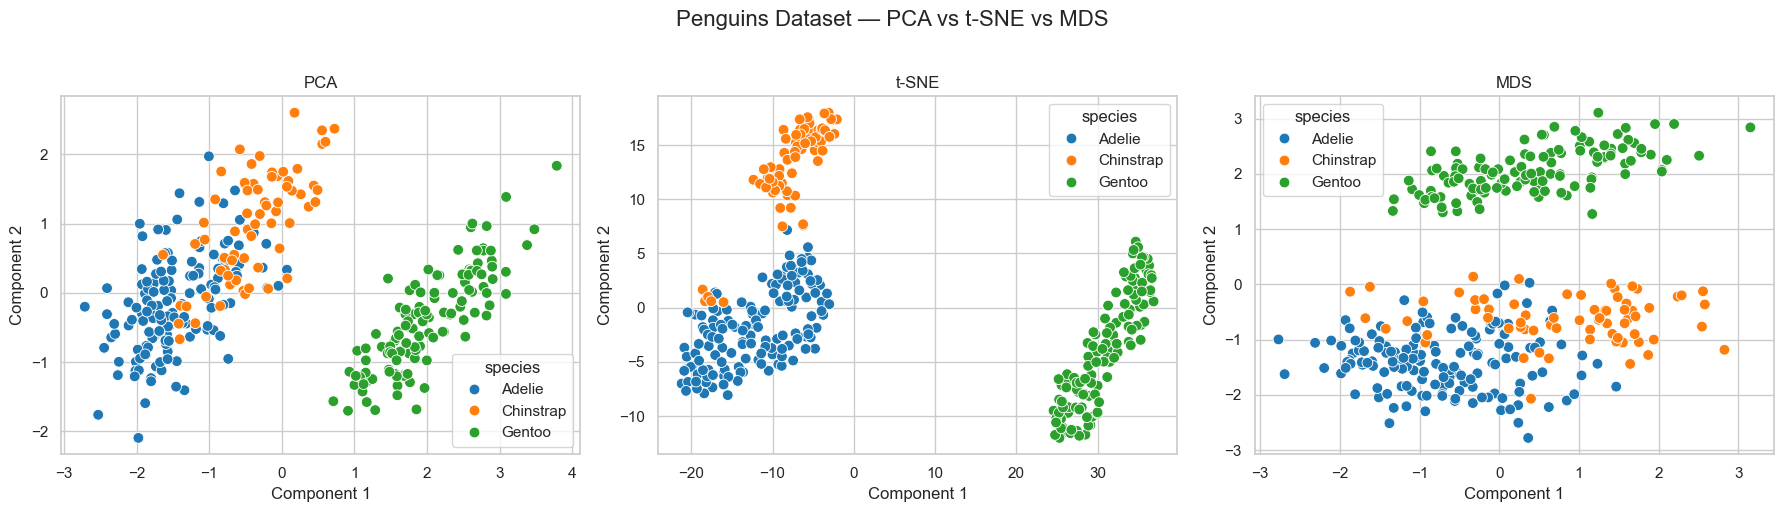

In [17]:
species_order = sorted(y_penguins.unique())
species_palette = dict(zip(species_order, sns.color_palette("tab10", len(species_order))))

projection_dfs = {
    "PCA": pd.DataFrame({
        "Dim1": X_penguins_pca[:, 0],
        "Dim2": X_penguins_pca[:, 1],
        "species": y_penguins.values,
    }),
    "t-SNE": pd.DataFrame({
        "Dim1": X_penguins_tsne[:, 0],
        "Dim2": X_penguins_tsne[:, 1],
        "species": y_penguins.values,
    }),
    "MDS": pd.DataFrame({
        "Dim1": X_penguins_mds[:, 0],
        "Dim2": X_penguins_mds[:, 1],
        "species": y_penguins.values,
    }),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (method_name, plot_df) in zip(axes, projection_dfs.items()):
    sns.scatterplot(
        data=plot_df,
        x="Dim1",
        y="Dim2",
        hue="species",
        hue_order=species_order,
        palette=species_palette,
        s=60,
        ax=ax
    )
    
    ax.set_title(method_name)
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")

plt.suptitle("Penguins Dataset — PCA vs t-SNE vs MDS", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

**Task 3 Interpretation**

PCA is a linear method, so it shows the strongest directions of variance in the data. It is useful and interpretable, but it may not capture nonlinear structure.

t-SNE is mainly used for visualization. It often creates visually separated groups, but the axes are not directly interpretable and distances between clusters can be misleading. It can also produce different-looking plots if the random state or parameters change.

MDS tries to preserve pairwise distances between points. It can be useful for comparing distance relationships, but it is usually slower than PCA.

In this Penguins dataset, I compare the plots visually to decide which method separates the three species most clearly.

## 5. Task 4 — Clustering Penguins Without Species Labels

In this task, I remove the species labels from the clustering process and apply K-Means with `k = 3`.

After clustering, I compare the predicted cluster labels with the true species labels using:

- Adjusted Rand Index (ARI)
- Normalized Mutual Information (NMI)

These metrics help evaluate whether unsupervised clustering rediscovered the known species structure.

### 5.1 K-Means on Label-Free Penguins Data

In [18]:
penguin_kmeans = KMeans(
    n_clusters=3,
    random_state=RANDOM_STATE,
    n_init=10
)

penguin_cluster_labels = penguin_kmeans.fit_predict(X_penguins_scaled)

print("Penguin K-Means cluster labels:", np.unique(penguin_cluster_labels))
print("Cluster sizes:", np.bincount(penguin_cluster_labels))
print("Silhouette score:", round(silhouette_score(X_penguins_scaled, penguin_cluster_labels), 3))

Penguin K-Means cluster labels: [0 1 2]
Cluster sizes: [129 119  85]
Silhouette score: 0.446


### 5.2 ARI and NMI Evaluation

In [19]:
ari_score = adjusted_rand_score(y_penguins, penguin_cluster_labels)
nmi_score = normalized_mutual_info_score(y_penguins, penguin_cluster_labels)

print(f"Adjusted Rand Index (ARI): {ari_score:.3f}")
print(f"Normalized Mutual Information (NMI): {nmi_score:.3f}")

Adjusted Rand Index (ARI): 0.799
Normalized Mutual Information (NMI): 0.790


**Metric Interpretation**

Adjusted Rand Index compares the similarity between true labels and cluster labels while correcting for chance. A higher value means better agreement.

Normalized Mutual Information measures how much information the cluster labels share with the true labels. A higher value means the clusters align better with the real species.

### 5.3 Visualize True Species vs K-Means Clusters

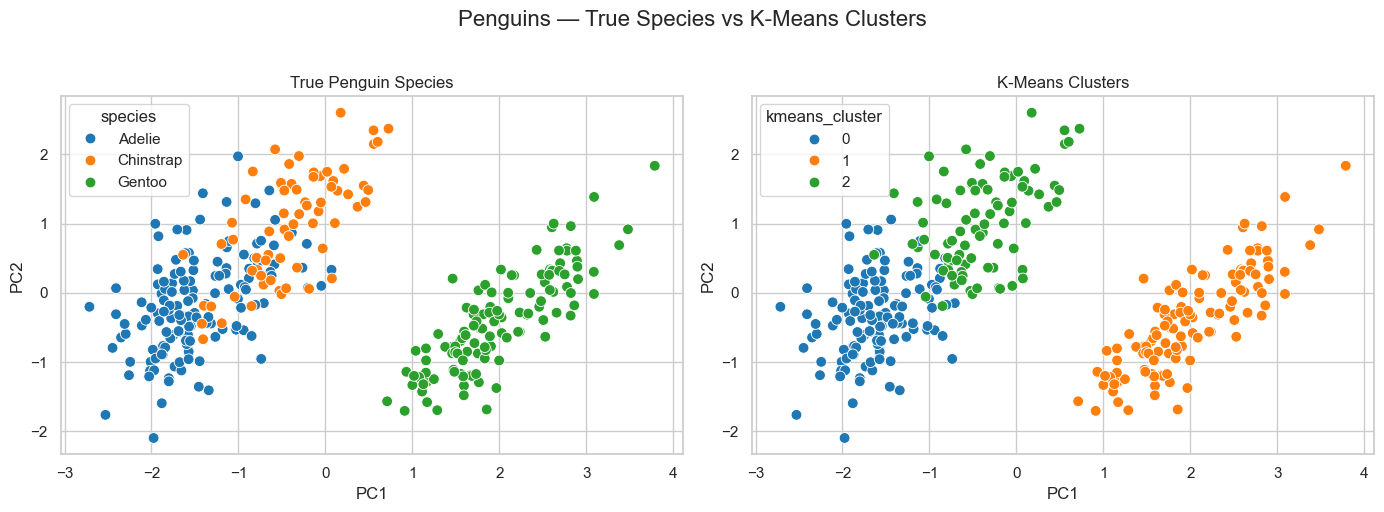

In [20]:
penguin_eval_df = pd.DataFrame({
    "PC1": X_penguins_pca[:, 0],
    "PC2": X_penguins_pca[:, 1],
    "species": y_penguins.values,
    "kmeans_cluster": penguin_cluster_labels,
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=penguin_eval_df,
    x="PC1",
    y="PC2",
    hue="species",
    hue_order=species_order,
    palette=species_palette,
    s=60,
    ax=axes[0]
)

axes[0].set_title("True Penguin Species")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

sns.scatterplot(
    data=penguin_eval_df,
    x="PC1",
    y="PC2",
    hue="kmeans_cluster",
    palette="tab10",
    s=60,
    ax=axes[1]
)

axes[1].set_title("K-Means Clusters")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

plt.suptitle("Penguins — True Species vs K-Means Clusters", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

In [21]:
comparison_table = pd.crosstab(
    penguin_eval_df["species"],
    penguin_eval_df["kmeans_cluster"],
    rownames=["True species"],
    colnames=["K-Means cluster"]
)

display(comparison_table)

K-Means cluster,0,1,2
True species,,,
Adelie,124,0,22
Chinstrap,5,0,63
Gentoo,0,119,0


**Task 4 Interpretation**

K-Means did not see the species labels during clustering. It only used the numeric measurements: bill length, bill depth, flipper length, and body mass.

The ARI and NMI scores show how closely the unsupervised clusters match the real species. The side-by-side PCA plot helps visually compare the true species structure against the discovered clusters.

If the scores are high and the plots look similar, then unsupervised learning partially rediscovered the species. If some groups overlap, it means the numeric features are not enough to perfectly separate all species or that K-Means assumptions do not fully match the real data structure.

## 6. Additional Task — Gaussian Mixture Model and BIC

This section is optional.

Gaussian Mixture Models provide soft clustering. Instead of assigning each point to exactly one cluster, GMM gives probabilities of belonging to each component.

BIC can help choose the number of components by balancing model fit and complexity.

In [22]:
from sklearn.mixture import GaussianMixture

bic_scores = []
component_range = range(1, 8)

for n_components in component_range:
    gmm = GaussianMixture(
        n_components=n_components,
        random_state=RANDOM_STATE
    )
    
    gmm.fit(X_wine_scaled)
    
    bic_scores.append(gmm.bic(X_wine_scaled))

gmm_bic_df = pd.DataFrame({
    "n_components": list(component_range),
    "BIC": bic_scores,
})

display(gmm_bic_df)

,n_components,BIC
0,1,5741.301901
1,2,5629.573389
2,3,5842.330292
3,4,5806.820274
4,5,6463.001990
5,6,6863.554404
6,7,6917.547168


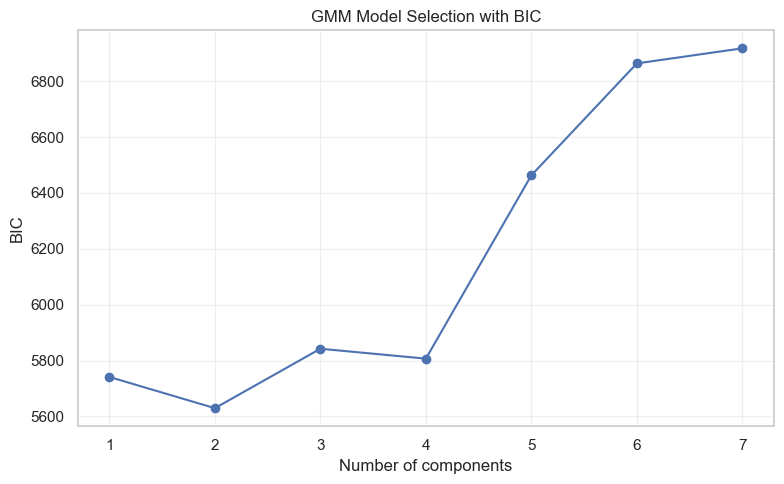

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(
    gmm_bic_df["n_components"],
    gmm_bic_df["BIC"],
    marker="o"
)

plt.title("GMM Model Selection with BIC")
plt.xlabel("Number of components")
plt.ylabel("BIC")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
best_n_components = gmm_bic_df.loc[gmm_bic_df["BIC"].idxmin(), "n_components"]

gmm_final = GaussianMixture(
    n_components=int(best_n_components),
    random_state=RANDOM_STATE
)

gmm_labels = gmm_final.fit_predict(X_wine_scaled)
gmm_probs = gmm_final.predict_proba(X_wine_scaled)

print("Best number of components by BIC:", best_n_components)
print("GMM cluster labels:", np.unique(gmm_labels))
print("First sample probabilities:", np.round(gmm_probs[0], 3))

Best number of components by BIC: 2
GMM cluster labels: [0 1]
First sample probabilities: [1. 0.]


**Additional Task Interpretation**

The BIC curve helps choose the number of GMM components. Lower BIC is better.

GMM is different from K-Means because it gives soft assignments. This means each data point can have probabilities of belonging to different clusters.

## 7. Final Summary

In this lab, I practiced unsupervised learning using clustering and dimensionality reduction.

### Main conclusions

- K-Means is simple and effective, but it requires choosing the number of clusters in advance.
- The elbow method and silhouette score help select a reasonable value for k.
- Agglomerative clustering builds a hierarchy of clusters and can be visualized with a dendrogram.
- DBSCAN can find noise and does not require k, but it is sensitive to `eps` and `min_samples`.
- PCA, t-SNE, and MDS reduce high-dimensional data to 2-D for visualization, but they preserve different kinds of structure.
- ARI and NMI help evaluate whether unsupervised clusters match known labels.

### Key learning

Unsupervised learning does not learn from labels. It discovers structure from the feature matrix. Labels can still be used after clustering to evaluate whether the discovered structure matches real-world categories.